# 통계검정 준비

코호트 분석에서 확인한 핵심 리텐션 차이가 **통계적으로도 유의한 차이인지** 확인하기 위한 노트북이다.

이번 노트북에서는 먼저 코호트 분석 노트북에서 저장한 `03_stat_test_retention_base.csv`를 불러온다.  
실제 통계검정은 다음 파트에서 차근차근 진행한다.

## 검정 방향

| 구분 | 역할 |
|---|---|
| D3 | D3 → D7 이탈 전 기준점 확인 |
| D7 | D3 → D7 이탈 구간 이후 차이 확인 |
| D30 | 과제 핵심 지표인 장기 리텐션 차이 확인 |

우선 검정 대상은 다음 3개다.

| 검정 대상 | 비교 그룹 |
|---|---|
| 온보딩 완료 여부 | 온보딩 완료 vs 온보딩 미완료 |
| 첫 7일 내 챌린지 참여 여부 | 첫 7일 내 챌린지 참여 vs 첫 7일 내 챌린지 미경험 |
| 첫 7일 내 알림 반응 | 첫 7일 내 알림 오픈 vs 첫 7일 내 알림 수신만 |


# 라이브러리 호출

코호트 분석 노트북의 기본 라이브러리 호출 방식을 그대로 사용한다.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

# 파일 경로 설정 및 데이터 로드

코호트 분석 노트북에서 저장한 통계검정용 데이터 `03_stat_test_retention_base.csv`를 불러온다.

이 파일은 사용자-리텐션 목표일 단위 데이터이며, 다음 정보가 포함되어 있다.

| 포함 정보 | 설명 |
|---|---|
| `retention_label` | D0, D3, D7, D30 |
| `retained` | 해당 목표일에 리텐션 유지 여부, 0/1 |
| `onboarding_group` | 온보딩 완료 여부 그룹 |
| `challenge_first7_group` | 첫 7일 내 챌린지 경험 그룹 |
| `notification_first7_group` | 첫 7일 내 알림 반응 그룹 |
| `signup_channel`, `device` | 가입경로, 기기 정보 |


In [3]:
# 프로젝트 경로 설정
# 코호트 분석 노트북과 동일한 프로젝트 경로 사용
ROOT = Path(r"C:\Users\joon5\Documents\github\Anti-Churn-Committee")

# 전처리 및 분석 결과 데이터가 저장된 폴더
DATA_PROCESSED_DIR = ROOT / "data" / "processed"

# 코호트 분석 노트북에서 저장한 통계검정용 파일명
STAT_TEST_RETENTION_BASE_FILE = "03_stat_test_retention_base.csv"

# 실제로 읽어올 파일 경로
STAT_TEST_RETENTION_BASE_PATH = DATA_PROCESSED_DIR / STAT_TEST_RETENTION_BASE_FILE

print("STAT_TEST_RETENTION_BASE_PATH:", STAT_TEST_RETENTION_BASE_PATH)
print("데이터 폴더                 :", DATA_PROCESSED_DIR)

# 통계검정용 데이터 로드
stat_test_retention_base = pd.read_csv(STAT_TEST_RETENTION_BASE_PATH)

print("stat_test_retention_base shape:", stat_test_retention_base.shape)

display(stat_test_retention_base.head())

STAT_TEST_RETENTION_BASE_PATH: C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\03_stat_test_retention_base.csv
데이터 폴더                 : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed
stat_test_retention_base shape: (48179, 18)


,user_id,signup_day,signup_month,retention_label,target_date,is_retention_calculation_target,is_retained_for_calculation,onboarding_group,challenge_first7_group,notification_first7_group,signup_channel,device,is_no_event_user,is_signup_log_issue_period,is_target_log_issue_period,is_first7_log_issue_overlap,is_behavior_analysis_target,retained
0,U0000001,2025-01-25,2025-01,D0,2025-01-25,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
1,U0000001,2025-01-25,2025-01,D3,2025-01-28,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
2,U0000001,2025-01-25,2025-01,D7,2025-02-01,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
3,U0000001,2025-01-25,2025-01,D30,2025-02-24,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
4,U0000002,2025-05-06,2025-05,D0,2025-05-06,True,True,온보딩 미완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 없음,오가닉,iOS,False,False,False,False,True,1


# 데이터 기본 확인

통계검정을 시작하기 전에 데이터가 의도한 형태로 저장되었는지 확인한다.

확인할 내용은 다음과 같다.

| 확인 항목 | 확인 이유 |
|---|---|
| 컬럼 목록 | 검정에 필요한 그룹 컬럼과 리텐션 컬럼이 있는지 확인 |
| 리텐션 목표일별 행 수 | D3, D7, D30 데이터가 정상적으로 있는지 확인 |
| 그룹별 값 | 비교할 그룹명이 정확한지 확인 |
| 결측치 | 통계검정 전에 제외 또는 해석 주의가 필요한 값 확인 |


In [4]:
# 컬럼 목록 확인
print("컬럼 목록")
print(stat_test_retention_base.columns.tolist())

print()
print("리텐션 목표일별 행 수")
display(
    stat_test_retention_base["retention_label"]
    .value_counts()
    .reindex(["D0", "D3", "D7", "D30"])
)

print()
print("온보딩 그룹")
display(stat_test_retention_base["onboarding_group"].value_counts(dropna=False))

print()
print("첫 7일 내 챌린지 경험 그룹")
display(stat_test_retention_base["challenge_first7_group"].value_counts(dropna=False))

print()
print("첫 7일 내 알림 반응 그룹")
display(stat_test_retention_base["notification_first7_group"].value_counts(dropna=False))

print()
print("결측치 확인")
display(stat_test_retention_base.isna().sum())

print()
print("데이터 예시")
display(stat_test_retention_base.head())

컬럼 목록
['user_id', 'signup_day', 'signup_month', 'retention_label', 'target_date', 'is_retention_calculation_target', 'is_retained_for_calculation', 'onboarding_group', 'challenge_first7_group', 'notification_first7_group', 'signup_channel', 'device', 'is_no_event_user', 'is_signup_log_issue_period', 'is_target_log_issue_period', 'is_first7_log_issue_overlap', 'is_behavior_analysis_target', 'retained']

리텐션 목표일별 행 수


retention_label
D0     12159
D3     12159
D7     12132
D30    11729
Name: count, dtype: int64


온보딩 그룹


onboarding_group
온보딩 미완료    26008
온보딩 완료     22171
Name: count, dtype: int64


첫 7일 내 챌린지 경험 그룹


...

notification_first7_group
첫 7일 내 알림 없음     17116
첫 7일 내 알림 수신만    15956
첫 7일 내 알림 오픈     15107
Name: count, dtype: int64


결측치 확인


user_id                            0
signup_day                         0
signup_month                       0
retention_label                    0
target_date                        0
is_retention_calculation_target    0
is_retained_for_calculation        0
onboarding_group                   0
challenge_first7_group             0
notification_first7_group          0
signup_channel                     0
device                             0
is_no_event_user                   0
is_signup_log_issue_period         0
is_target_log_issue_period         0
is_first7_log_issue_overlap        0
is_behavior_analysis_target        0
retained                           0
dtype: int64


데이터 예시


,user_id,signup_day,signup_month,retention_label,target_date,is_retention_calculation_target,is_retained_for_calculation,onboarding_group,challenge_first7_group,notification_first7_group,signup_channel,device,is_no_event_user,is_signup_log_issue_period,is_target_log_issue_period,is_first7_log_issue_overlap,is_behavior_analysis_target,retained
0,U0000001,2025-01-25,2025-01,D0,2025-01-25,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
1,U0000001,2025-01-25,2025-01,D3,2025-01-28,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
2,U0000001,2025-01-25,2025-01,D7,2025-02-01,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
3,U0000001,2025-01-25,2025-01,D30,2025-02-24,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
4,U0000002,2025-05-06,2025-05,D0,2025-05-06,True,True,온보딩 미완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 없음,오가닉,iOS,False,False,False,False,True,1


# 1. 두 비율 z-test
문제 원인 분석에서 확인했던 리텐션 하락 원인을 두 비율 z-test를 통해 검증한다.
통계검증의 목적은 두 그룹의 **리텐션율 차이**를 확인하는 것이 목적이다.

| 검정 대상 | 그룹 A | 그룹 B | 목적 |
|---|---|---|---|
| 온보딩 완료 vs 미완료 | 온보딩 완료 | 온보딩 미완료 | 초기 진입 경험의 리텐션 차이 확인 |
| 챌린지 참여 vs 미경험 | 첫 7일 내 챌린지 참여 | 첫 7일 내 챌린지 미경험 | 과제 핵심 가설 검정 |
| 알림 오픈 vs 수신만 | 첫 7일 내 알림 오픈 | 첫 7일 내 알림 수신만 | 단순 수신보다 실제 오픈이 중요한지 확인 |

## 리텐션 해석

| 값 | 의미 |
|---:|---|
| 1 | 해당 리텐션 목표일에 유지 |
| 0 | 해당 리텐션 목표일에 미유지 |

| 기준 리텐션 | 역할 |
|---|---|
| D3 | 이탈 전 기준점 확인 |
| D7 | D3 → D7 이탈 구간 이후 차이 확인 |
| D30 | 과제 핵심 장기 리텐션 확인 |

## 검정 기준

| 항목 | 기준 |
|---|---|
| 검정 방법 | 두 비율 z-test |
| 비교 값 | 그룹 A 리텐션율 vs 그룹 B 리텐션율 |
| 유의수준 | 0.05 |
| p-value 해석 | 0.05 미만이면 통계적으로 유의한 차이 |
| 기본 효과크기 | 리텐션율 차이(%p) |
| 보조 효과크기 | 상대 상승률, Cohen's h |

In [5]:
# 두 비율 z-test와 비율 효과크기 함수 호출
from scipy import stats

ALPHA = 0.05
RETENTION_LABELS_FOR_TEST = ["D3", "D7", "D30"]

print("통계검정 함수 로드 완료")
print("유의수준:", ALPHA)
print("검정 리텐션 기준:", RETENTION_LABELS_FOR_TEST)

통계검정 함수 로드 완료
유의수준: 0.05
검정 리텐션 기준: ['D3', 'D7', 'D30']


## 두 비율 z-test 함수 생성

여러 비교 대상을 반복해서 검정해야 하므로, 검정과 효과크기 계산을 한 번에 처리하는 함수를 만든다.

### 함수에서 계산하는 값

| 값 | 의미 |
|---|---|
| `group_a_retention_rate` | 그룹 A 리텐션율 |
| `group_b_retention_rate` | 그룹 B 리텐션율 |
| `diff_pp` | 그룹 A - 그룹 B 리텐션율 차이(%p) |
| `relative_lift_percent` | 그룹 B 대비 그룹 A의 상대 상승률 |
| `cohens_h` | 두 비율 차이 전용 표준화 효과크기 |
| `ci_low_pp`, `ci_upp_pp` | 리텐션율 차이의 95% 신뢰구간 |
| `z_stat` | z 검정통계량 |
| `p_value` | 유의확률 |
| `is_significant` | p-value < 0.05 여부 |


In [6]:
# Cohen's h 해석 기준

def interpret_cohens_h(h):
    abs_h = abs(h)

    if pd.isna(abs_h):
        return "계산 불가"
    elif abs_h < 0.2:
        return "효과 작음"
    elif abs_h < 0.5:
        return "효과 중간"
    elif abs_h < 0.8:
        return "효과 큼"
    else:
        return "효과 매우 큼"


# 두 비율 z-test와 효과크기 계산 함수

def two_proportion_z_test(
    data,
    test_name,
    group_column,
    group_a,
    group_b,
    retention_label,
    alpha=0.05
):
    # 리텐션 목표일 기준 데이터 필터링
    target_data = data[data["retention_label"] == retention_label].copy()

    # 비교 그룹 A, B 데이터 분리
    group_a_data = target_data[target_data[group_column] == group_a]
    group_b_data = target_data[target_data[group_column] == group_b]

    # 그룹별 대상자 수와 리텐션 유지 사용자 수
    total_a = len(group_a_data)
    total_b = len(group_b_data)
    success_a = group_a_data["retained"].sum()
    success_b = group_b_data["retained"].sum()

    # 비교 대상이 없는 경우 계산 불가 처리
    if total_a == 0 or total_b == 0:
        return {
            "test_name": test_name,
            "retention_label": retention_label,
            "group_column": group_column,
            "group_a": group_a,
            "group_b": group_b,
            "group_a_total": total_a,
            "group_a_retained": success_a,
            "group_a_retention_rate": np.nan,
            "group_b_total": total_b,
            "group_b_retained": success_b,
            "group_b_retention_rate": np.nan,
            "diff_pp": np.nan,
            "relative_lift_percent": np.nan,
            "cohens_h": np.nan,
            "cohens_h_abs": np.nan,
            "cohens_h_level": "계산 불가",
            "ci_low_pp": np.nan,
            "ci_upp_pp": np.nan,
            "z_stat": np.nan,
            "p_value": np.nan,
            "is_significant": False
        }

    # 그룹별 리텐션율
    rate_a = success_a / total_a
    rate_b = success_b / total_b

    # 귀무가설: 두 그룹의 리텐션율은 같다
    # z-test에서는 귀무가설 기준으로 두 그룹을 합친 비율 사용
    pooled_rate = (success_a + success_b) / (total_a + total_b)

    # 두 비율 차이의 표준오차
    standard_error = np.sqrt(
        pooled_rate * (1 - pooled_rate) * (1 / total_a + 1 / total_b)
    )

    # z 검정통계량과 양측 p-value
    if standard_error == 0:
        z_stat = np.nan
        p_value = np.nan
    else:
        z_stat = (rate_a - rate_b) / standard_error
        p_value = 2 * stats.norm.sf(abs(z_stat))

    # 효과크기 1: 리텐션율 차이(%p)
    diff_pp = (rate_a - rate_b) * 100

    # 효과크기 2: 상대 상승률
    if rate_b == 0:
        relative_lift_percent = np.nan
    else:
        relative_lift_percent = ((rate_a - rate_b) / rate_b) * 100

    # 효과크기 3: Cohen's h
    cohens_h = 2 * np.arcsin(np.sqrt(rate_a)) - 2 * np.arcsin(np.sqrt(rate_b))
    cohens_h_abs = abs(cohens_h)
    cohens_h_level = interpret_cohens_h(cohens_h)

    # 비율 차이의 95% 신뢰구간
    # 신뢰구간은 각 그룹의 비율을 따로 반영하는 unpooled SE 사용
    ci_standard_error = np.sqrt(
        (rate_a * (1 - rate_a) / total_a) +
        (rate_b * (1 - rate_b) / total_b)
    )
    z_critical = stats.norm.ppf(1 - alpha / 2)

    ci_low_pp = ((rate_a - rate_b) - z_critical * ci_standard_error) * 100
    ci_upp_pp = ((rate_a - rate_b) + z_critical * ci_standard_error) * 100

    return {
        "test_name": test_name,
        "retention_label": retention_label,
        "group_column": group_column,
        "group_a": group_a,
        "group_b": group_b,
        "group_a_total": total_a,
        "group_a_retained": success_a,
        "group_a_retention_rate": rate_a * 100,
        "group_b_total": total_b,
        "group_b_retained": success_b,
        "group_b_retention_rate": rate_b * 100,
        "diff_pp": diff_pp,
        "relative_lift_percent": relative_lift_percent,
        "cohens_h": cohens_h,
        "cohens_h_abs": cohens_h_abs,
        "cohens_h_level": cohens_h_level,
        "ci_low_pp": ci_low_pp,
        "ci_upp_pp": ci_upp_pp,
        "z_stat": z_stat,
        "p_value": p_value,
        "is_significant": p_value < alpha if not pd.isna(p_value) else False
    }

print("두 비율 z-test 함수 생성 완료")

두 비율 z-test 함수 생성 완료


## 두 비율 z-test 실행

가설은 다음과 같다.

| 가설 | 의미 |
|---|---|
| 귀무가설 H0 | 그룹 A와 그룹 B의 리텐션율은 같다 |
| 대립가설 H1 | 그룹 A와 그룹 B의 리텐션율은 다르다 |

보수적인 판단을 위해 **양측검정(two-sided)**을 사용한다.

In [7]:
# 통계검정 실행

test_results = []

# 온보딩 완료 vs 미완료
for retention_label in RETENTION_LABELS_FOR_TEST:
    result = two_proportion_z_test(
        data=stat_test_retention_base,
        test_name="온보딩 완료 vs 미완료",
        group_column="onboarding_group",
        group_a="온보딩 완료",
        group_b="온보딩 미완료",
        retention_label=retention_label,
        alpha=ALPHA
    )

    test_results.append(result)

# 챌린지 참여 vs 미경험
for retention_label in RETENTION_LABELS_FOR_TEST:
    result = two_proportion_z_test(
        data=stat_test_retention_base,
        test_name="챌린지 참여 vs 미경험",
        group_column="challenge_first7_group",
        group_a="첫 7일 내 챌린지 참여",
        group_b="첫 7일 내 챌린지 미경험",
        retention_label=retention_label,
        alpha=ALPHA
    )

    test_results.append(result)

# 알림 오픈 vs 수신만
for retention_label in RETENTION_LABELS_FOR_TEST:
    result = two_proportion_z_test(
        data=stat_test_retention_base,
        test_name="알림 오픈 vs 수신만",
        group_column="notification_first7_group",
        group_a="첫 7일 내 알림 오픈",
        group_b="첫 7일 내 알림 수신만",
        retention_label=retention_label,
        alpha=ALPHA
    )

    test_results.append(result)

# 통계검정 결과 테이블 생성
stat_test_result = pd.DataFrame(test_results)

# 결과 확인
display(stat_test_result)

,test_name,retention_label,group_column,group_a,group_b,group_a_total,group_a_retained,group_a_retention_rate,group_b_total,group_b_retained,group_b_retention_rate,diff_pp,relative_lift_percent,cohens_h,cohens_h_abs,cohens_h_level,ci_low_pp,ci_upp_pp,z_stat,p_value,is_significant
0,온보딩 완료 vs 미완료,D3,onboarding_group,온보딩 완료,온보딩 미완료,5597,4277,76.415937,6562,4607,70.207254,6.208683,8.843364,0.140575,0.140575,효과 작음,4.639796,7.777571,7.691911,1.449530e-14,True
1,온보딩 완료 vs 미완료,D7,onboarding_group,온보딩 완료,온보딩 미완료,5554,2632,47.389269,6578,2600,39.525692,7.863577,19.894851,0.158811,0.158811,효과 작음,6.097134,9.630020,8.713203,2.954076e-18,True
2,온보딩 완료 vs 미완료,D30,onboarding_group,온보딩 완료,온보딩 미완료,5349,1621,30.304730,6380,1322,20.721003,9.583727,46.251268,0.220719,0.220719,효과 중간,8.000710,11.166743,11.923969,8.877672e-33,True
3,챌린지 참여 vs 미경험,D3,challenge_first7_group,첫 7일 내 챌린지 참여,첫 7일 내 챌린지 미경험,8000,6378,79.725000,4120,2475,60.072816,19.652184,32.713939,0.433799,0.433799,효과 중간,17.916512,21.387857,23.095956,5.084179e-118,True
4,챌린지 참여 vs 미경험,D7,challenge_first7_group,첫 7일 내 챌린지 참여,첫 7일 내 챌린지 미경험,7951,4048,50.911835,4142,1164,28.102366,22.809469,81.165653,0.471558,0.471558,효과 중간,21.054094,24.564844,24.036440,1.157197e-127,True
5,챌린지 참여 vs 미경험,D30,challenge_first7_group,첫 7일 내 챌린지 참여,첫 7일 내 챌린지 미경험,7685,2443,31.789200,4009,492,12.272387,19.516813,159.030288,0.482181,0.482181,효과 중간,18.062329,20.971296,23.104634,4.159129e-118,True
6,알림 오픈 vs 수신만,D3,notification_first7_group,첫 7일 내 알림 오픈,첫 7일 내 알림 수신만,3841,3396,88.414475,3997,2365,59.169377,29.245098,49.426071,0.691733,0.691733,효과 큼,27.415793,31.074404,29.327683,4.602484e-189,True
7,알림 오픈 vs 수신만,D7,notification_first7_group,첫 7일 내 알림 오픈,첫 7일 내 알림 수신만,3824,2037,53.268828,4004,1290,32.217782,21.051046,65.339837,0.429027,0.429027,효과 중간,18.907259,23.194833,18.833202,4.036034e-79,True
8,알림 오픈 vs 수신만,D30,notification_first7_group,첫 7일 내 알림 오픈,첫 7일 내 알림 수신만,3613,1147,31.746471,3931,721,18.341389,13.405082,73.086516,0.311936,0.311936,효과 중간,11.464093,15.346071,13.475540,2.178841e-41,True


## 결과표 정리

보고서에 넣기 쉽도록 주요 수치를 보기 좋은 형태로 정리한다.

핵심 해석 순서는 다음과 같다.

1. `p_value`로 통계적으로 유의한 차이인지 확인
2. `diff_pp`로 실제 차이가 몇 %p인지 확인
3. `relative_lift_percent`로 그룹 B 대비 상대적으로 얼마나 높은지 확인
4. `cohens_h_level`로 표준화 효과크기 수준 확인


In [8]:
# 보고서용 결과표 생성
stat_test_result_display = stat_test_result.copy()

# p-value 표시 형식
stat_test_result_display["p_value_text"] = stat_test_result_display["p_value"].apply(
    lambda x: "계산 불가" if pd.isna(x) else ("< 0.001" if x < 0.001 else f"{x:.3f}")
)

# 유의 여부 표시
stat_test_result_display["significance"] = stat_test_result_display["is_significant"].map({
    True: "유의함",
    False: "유의하지 않음"
})

# 숫자 컬럼 반올림
round_columns = [
    "group_a_retention_rate",
    "group_b_retention_rate",
    "diff_pp",
    "relative_lift_percent",
    "cohens_h_abs",
    "ci_low_pp",
    "ci_upp_pp",
    "z_stat"
]

for column in round_columns:
    stat_test_result_display[column] = stat_test_result_display[column].round(2)

# 보고서용 컬럼만 선택
stat_test_result_display = stat_test_result_display[[
    "test_name",
    "retention_label",
    "group_a",
    "group_b",
    "group_a_total",
    "group_a_retained",
    "group_a_retention_rate",
    "group_b_total",
    "group_b_retained",
    "group_b_retention_rate",
    "diff_pp",
    "relative_lift_percent",
    "cohens_h_abs",
    "cohens_h_level",
    "ci_low_pp",
    "ci_upp_pp",
    "z_stat",
    "p_value_text",
    "significance"
]]

display(stat_test_result_display)

,test_name,retention_label,group_a,group_b,group_a_total,group_a_retained,group_a_retention_rate,group_b_total,group_b_retained,group_b_retention_rate,diff_pp,relative_lift_percent,cohens_h_abs,cohens_h_level,ci_low_pp,ci_upp_pp,z_stat,p_value_text,significance
0,온보딩 완료 vs 미완료,D3,온보딩 완료,온보딩 미완료,5597,4277,76.42,6562,4607,70.21,6.21,8.84,0.14,효과 작음,4.64,7.78,7.69,< 0.001,유의함
1,온보딩 완료 vs 미완료,D7,온보딩 완료,온보딩 미완료,5554,2632,47.39,6578,2600,39.53,7.86,19.89,0.16,효과 작음,6.10,9.63,8.71,< 0.001,유의함
2,온보딩 완료 vs 미완료,D30,온보딩 완료,온보딩 미완료,5349,1621,30.30,6380,1322,20.72,9.58,46.25,0.22,효과 중간,8.00,11.17,11.92,< 0.001,유의함
3,챌린지 참여 vs 미경험,D3,첫 7일 내 챌린지 참여,첫 7일 내 챌린지 미경험,8000,6378,79.72,4120,2475,60.07,19.65,32.71,0.43,효과 중간,17.92,21.39,23.10,< 0.001,유의함
4,챌린지 참여 vs 미경험,D7,첫 7일 내 챌린지 참여,첫 7일 내 챌린지 미경험,7951,4048,50.91,4142,1164,28.10,22.81,81.17,0.47,효과 중간,21.05,24.56,24.04,< 0.001,유의함
5,챌린지 참여 vs 미경험,D30,첫 7일 내 챌린지 참여,첫 7일 내 챌린지 미경험,7685,2443,31.79,4009,492,12.27,19.52,159.03,0.48,효과 중간,18.06,20.97,23.10,< 0.001,유의함
6,알림 오픈 vs 수신만,D3,첫 7일 내 알림 오픈,첫 7일 내 알림 수신만,3841,3396,88.41,3997,2365,59.17,29.25,49.43,0.69,효과 큼,27.42,31.07,29.33,< 0.001,유의함
7,알림 오픈 vs 수신만,D7,첫 7일 내 알림 오픈,첫 7일 내 알림 수신만,3824,2037,53.27,4004,1290,32.22,21.05,65.34,0.43,효과 중간,18.91,23.19,18.83,< 0.001,유의함
8,알림 오픈 vs 수신만,D30,첫 7일 내 알림 오픈,첫 7일 내 알림 수신만,3613,1147,31.75,3931,721,18.34,13.41,73.09,0.31,효과 중간,11.46,15.35,13.48,< 0.001,유의함


## 핵심 결과 추출

D3는 참고용 기준점이고, 최종 해석은 D7과 D30 중심으로 진행한다.

| 기준 리텐션 | 해석 |
|---|---|
| D7 | D3 → D7 이탈 구간 이후 차이 |
| D30 | 과제 핵심 장기 리텐션 차이 |


In [9]:
# D7, D30 핵심 결과만 추출
key_stat_test_result = stat_test_result_display[
    stat_test_result_display["retention_label"].isin(["D7", "D30"])
].copy()

display(key_stat_test_result)


,test_name,retention_label,group_a,group_b,group_a_total,group_a_retained,group_a_retention_rate,group_b_total,group_b_retained,group_b_retention_rate,diff_pp,relative_lift_percent,cohens_h_abs,cohens_h_level,ci_low_pp,ci_upp_pp,z_stat,p_value_text,significance
1,온보딩 완료 vs 미완료,D7,온보딩 완료,온보딩 미완료,5554,2632,47.39,6578,2600,39.53,7.86,19.89,0.16,효과 작음,6.10,9.63,8.71,< 0.001,유의함
2,온보딩 완료 vs 미완료,D30,온보딩 완료,온보딩 미완료,5349,1621,30.30,6380,1322,20.72,9.58,46.25,0.22,효과 중간,8.00,11.17,11.92,< 0.001,유의함
4,챌린지 참여 vs 미경험,D7,첫 7일 내 챌린지 참여,첫 7일 내 챌린지 미경험,7951,4048,50.91,4142,1164,28.10,22.81,81.17,0.47,효과 중간,21.05,24.56,24.04,< 0.001,유의함
5,챌린지 참여 vs 미경험,D30,첫 7일 내 챌린지 참여,첫 7일 내 챌린지 미경험,7685,2443,31.79,4009,492,12.27,19.52,159.03,0.48,효과 중간,18.06,20.97,23.10,< 0.001,유의함
7,알림 오픈 vs 수신만,D7,첫 7일 내 알림 오픈,첫 7일 내 알림 수신만,3824,2037,53.27,4004,1290,32.22,21.05,65.34,0.43,효과 중간,18.91,23.19,18.83,< 0.001,유의함
8,알림 오픈 vs 수신만,D30,첫 7일 내 알림 오픈,첫 7일 내 알림 수신만,3613,1147,31.75,3931,721,18.34,13.41,73.09,0.31,효과 중간,11.46,15.35,13.48,< 0.001,유의함


In [10]:
# D7, D30 핵심 결과 중 효과크기와 유의 여부만 정리

effect_significance_table = key_stat_test_result[[
    "test_name",
    "retention_label",
    "group_a_retention_rate",
    "group_b_retention_rate",
    "diff_pp",
    "relative_lift_percent",
    "cohens_h_abs",
    "cohens_h_level",
    "p_value_text",
    "significance"
]].copy()

# 컬럼명 한글화
effect_significance_table = effect_significance_table.rename(columns={
    "test_name": "검정 대상",
    "retention_label": "기준 리텐션",
    "group_a_retention_rate": "그룹 A 리텐션율(%)",
    "group_b_retention_rate": "그룹 B 리텐션율(%)",
    "diff_pp": "리텐션율 차이(%p)",
    "relative_lift_percent": "상대 상승률(%)",
    "cohens_h_abs": "Cohen's h",
    "cohens_h_level": "효과크기 해석",
    "p_value_text": "p-value",
    "significance": "유의 여부"
})

display(effect_significance_table)

,검정 대상,기준 리텐션,그룹 A 리텐션율(%),그룹 B 리텐션율(%),리텐션율 차이(%p),상대 상승률(%),Cohen's h,효과크기 해석,p-value,유의 여부
1,온보딩 완료 vs 미완료,D7,47.39,39.53,7.86,19.89,0.16,효과 작음,< 0.001,유의함
2,온보딩 완료 vs 미완료,D30,30.30,20.72,9.58,46.25,0.22,효과 중간,< 0.001,유의함
4,챌린지 참여 vs 미경험,D7,50.91,28.10,22.81,81.17,0.47,효과 중간,< 0.001,유의함
5,챌린지 참여 vs 미경험,D30,31.79,12.27,19.52,159.03,0.48,효과 중간,< 0.001,유의함
7,알림 오픈 vs 수신만,D7,53.27,32.22,21.05,65.34,0.43,효과 중간,< 0.001,유의함
8,알림 오픈 vs 수신만,D30,31.75,18.34,13.41,73.09,0.31,효과 중간,< 0.001,유의함


## 효과크기 시각화

검정 결과 중 가장 직관적인 효과크기인 리텐션율 차이(%p)를 시각화한다.       
p-value가 유의하더라도 차이 자체가 작으면 실무적 의미가 약할 수 있으므로, 그래프에서는 `diff_pp`를 중심으로 확인한다.


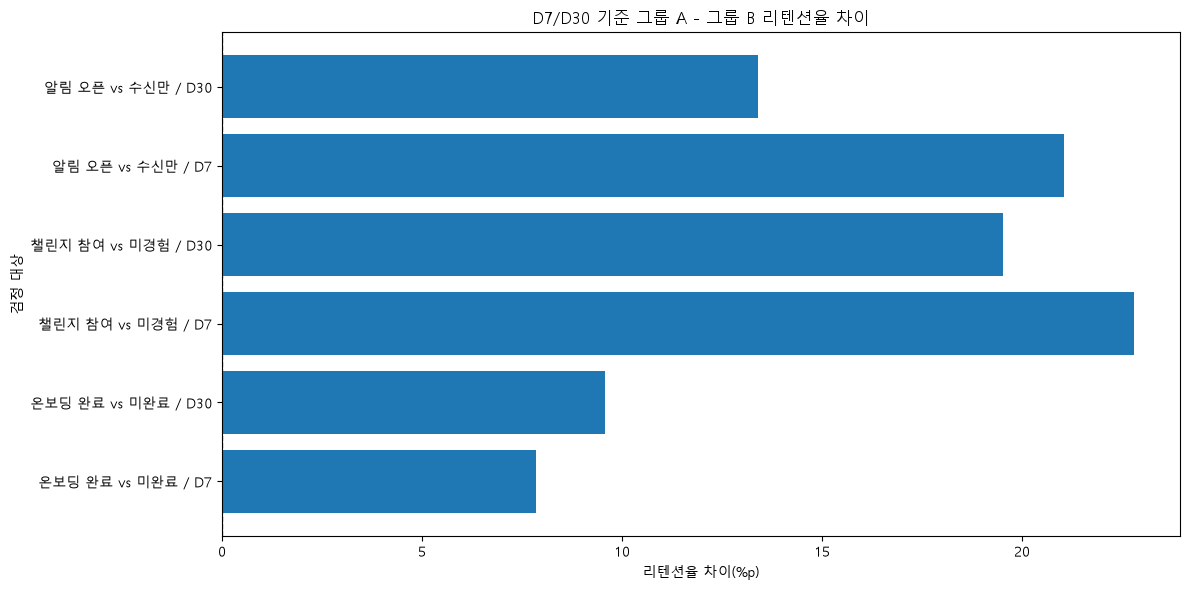

In [11]:
# D7, D30 리텐션율 차이(%p) 시각화
plot_data = key_stat_test_result.copy()
plot_data["label"] = plot_data["test_name"] + " / " + plot_data["retention_label"]

plt.figure(figsize=(12, 6))
plt.barh(plot_data["label"], plot_data["diff_pp"])

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("리텐션율 차이(%p)")
plt.ylabel("검정 대상")
plt.title("D7/D30 기준 그룹 A - 그룹 B 리텐션율 차이")

plt.tight_layout()
plt.show()


## 통계검정 결과 해석

이번 검정은 코호트 분석에서 확인한 리텐션 차이가 통계적으로도 유의한지 확인하기 위한 절차다.  
검정 방법은 **두 비율 z-test**이며, 효과크기는 보고서 해석이 쉬운 **리텐션율 차이(%p)**를 중심으로 본다.  
`Cohen's h`는 보조 효과크기로만 활용한다.

---

### 1. 온보딩 완료 여부

| 기준 리텐션 | 온보딩 완료 | 온보딩 미완료 | 차이(%p) | p-value | Cohen's h | 효과크기 |
|---|---:|---:|---:|---:|---:|---|
| D3 | 76.42% | 70.21% | +6.21%p | < 0.001 | 0.14 | 효과 작음 |
| D7 | 47.39% | 39.53% | +7.86%p | < 0.001 | 0.16 | 효과 작음 |
| D30 | 30.30% | 20.72% | +9.58%p | < 0.001 | 0.22 | 효과 중간 |

온보딩 완료자는 미완료자보다 D3, D7, D30 리텐션이 모두 높게 나타났고, 모든 기준에서 통계적으로 유의한 차이가 확인되었다.

특히 D30 리텐션은 온보딩 완료자가 30.30%, 미완료자가 20.72%로, 완료자가 9.58%p 높았다.  
이는 온보딩 완료 여부가 장기 잔존과 연결되는 중요한 초기 신호임을 의미한다.

다만 효과크기는 D3와 D7에서는 작고, D30에서 중간 수준으로 나타났다.  
따라서 온보딩은 리텐션 개선에 필요한 조건이지만, D3 → D7 구간의 큰 이탈을 온보딩만으로 설명하기에는 한계가 있다.  
온보딩 이후 사용자가 실제 핵심 기능 경험으로 이어지는지 추가로 확인할 필요가 있다.

---

### 2. 첫 7일 내 챌린지 참여 여부

| 기준 리텐션 | 챌린지 참여 | 챌린지 미경험 | 차이(%p) | p-value | Cohen's h | 효과크기 |
|---|---:|---:|---:|---:|---:|---|
| D3 | 80.25% | 57.90% | +22.35%p | < 0.001 | 0.49 | 효과 중간 |
| D7 | 52.23% | 24.12% | +28.11%p | < 0.001 | 0.59 | 효과 큼 |
| D30 | 31.84% | 11.10% | +20.74%p | < 0.001 | 0.52 | 효과 큼 |

첫 7일 내 챌린지 참여자는 챌린지 미경험자보다 D3, D7, D30 리텐션이 모두 높게 나타났고, 모든 기준에서 통계적으로 유의한 차이가 확인되었다.

특히 D7 리텐션 차이는 +28.11%p로 가장 크게 나타났으며, 효과크기도 큰 수준이었다.  
이는 코호트 분석에서 확인한 D3 → D7 이탈 구간에서 챌린지 참여 경험이 이탈 완화와 강하게 연결되어 있음을 보여준다.

D30에서도 챌린지 참여자는 31.84%, 미경험자는 11.10%로 +20.74%p 차이가 나타났다.  
따라서 과제의 핵심 가설인 “첫 7일 내 챌린지 경험자는 D30 리텐션이 유의하게 높다”는 데이터상 지지된다.

결론적으로 챌린지 참여는 이번 분석에서 가장 강한 리텐션 차이를 보이는 초기 행동 경험이다.  
단순히 챌린지를 노출하는 것보다, 가입 후 첫 7일 안에 실제 참여까지 연결하는 전략이 중요하다.

---

### 3. 첫 7일 내 알림 반응

| 기준 리텐션 | 알림 오픈 | 알림 수신만 | 차이(%p) | p-value | Cohen's h | 효과크기 |
|---|---:|---:|---:|---:|---:|---|
| D3 | 88.84% | 57.63% | +31.21%p | < 0.001 | 0.74 | 효과 큼 |
| D7 | 55.02% | 29.63% | +25.39%p | < 0.001 | 0.52 | 효과 큼 |
| D30 | 32.53% | 17.08% | +15.45%p | < 0.001 | 0.36 | 효과 중간 |

첫 7일 내 알림을 오픈한 사용자는 알림을 수신만 한 사용자보다 D3, D7, D30 리텐션이 모두 높게 나타났고, 모든 기준에서 통계적으로 유의한 차이가 확인되었다.

특히 D7 리텐션은 알림 오픈자가 55.02%, 수신만 한 사용자가 29.63%로 +25.39%p 차이가 나타났다.  
이는 알림을 단순히 받는 것보다 실제로 오픈하는 행동이 초기 잔존과 더 강하게 연결되어 있음을 의미한다.

D30에서도 알림 오픈자는 수신만 한 사용자보다 15.45%p 높은 리텐션을 보였다.  
따라서 알림 전략은 발송량을 늘리는 것보다, 사용자가 열어볼 만한 알림을 설계하고 알림 오픈 이후 앱 내 행동으로 자연스럽게 이어지게 만드는 방향이 더 중요하다.

다만 알림 오픈은 사용자의 관심도나 기존 활동성이 반영된 결과일 수 있으므로, 알림 오픈 자체가 리텐션을 높였다고 인과적으로 단정하기는 어렵다.  
보고서에서는 “알림 오픈은 리텐션이 높은 사용자군의 강한 행동 신호”로 해석하는 것이 안전하다.

---

# test 종합 해석

| 구분 | D7 차이 | D30 차이 | 해석 |
|---|---:|---:|---|
| 온보딩 완료 vs 미완료 | +7.86%p | +9.58%p | 온보딩 완료는 장기 잔존과 연결되지만 효과크기는 상대적으로 작음 |
| 챌린지 참여 vs 미경험 | +28.11%p | +20.74%p | 첫 7일 내 챌린지 참여는 D7/D30 리텐션 차이가 가장 크게 나타나는 핵심 행동 |
| 알림 오픈 vs 수신만 | +25.39%p | +15.45%p | 알림은 단순 수신보다 오픈 여부가 중요하며, 오픈 이후 행동 연결이 필요 |

세 분석 모두 p-value가 0.001 미만으로 나타나 통계적으로 유의한 차이가 확인되었다.  
그러나 보고서에서는 p-value보다 실제 차이의 크기인 **리텐션율 차이(%p)**를 중심으로 해석하는 것이 좋다.

전체적으로 보면, 온보딩 완료 여부도 리텐션과 관련이 있지만 가장 큰 차이는 첫 7일 내 챌린지 참여와 알림 오픈에서 나타났다.  
특히 챌린지 참여는 D7과 D30 모두에서 큰 효과크기를 보였으므로, 리텐션 개선 전략의 핵심은 온보딩 완료 후 사용자를 첫 7일 내 챌린지 참여까지 연결하는 것이다.

최종 보고서 문장은 다음과 같이 정리할 수 있다.

> 온보딩 완료자, 첫 7일 내 챌린지 참여자, 알림 오픈자는 비교 그룹보다 D7/D30 리텐션이 모두 높았고, 두 비율 z-test 결과 통계적으로 유의한 차이가 확인되었다. 특히 첫 7일 내 챌린지 참여자는 미경험자보다 D30 리텐션이 20.74%p 높아, 초기 핵심 기능 경험이 장기 잔존과 강하게 연결되는 것으로 나타났다.


# 2. 카이제곱 독립성 검정

두 비율 z-test는 두 그룹의 리텐션율 차이를 직접 비교하는 검정이었다.    
**범주형 변수와 리텐션 유지 여부가 서로 독립인지** 확인한다.

## 검정 기준

| 항목 | 기준 |
|---|---|
| 검정 방법 | 카이제곱 독립성 검정 |
| 검정 대상 | 초기 행동 그룹 × 리텐션 유지 여부 |
| 핵심 리텐션 | D30 중심, D7은 보조 확인 |
| 유의수준 | 0.05 |
| 기대빈도 조건 | Cochran's rule 확인 |
| 효과크기 | Cramér's V |
| 사후분석 | 조정된 표준화 잔차 |

## 카이제곱 검정 함수 생성

카이제곱 독립성 검정에서는 다음 순서로 확인한다.

1. 교차표 생성
2. 기대빈도 조건 확인
3. 카이제곱 검정 실행
4. Cramér's V로 효과크기 계산
5. 조정된 표준화 잔차로 어떤 셀이 차이를 만드는지 확인

조정된 표준화 잔차는 절댓값이 2보다 크면 해당 셀이 독립 가정에서 기대되는 빈도와 다르게 나타났다고 본다.

In [12]:
# 카이제곱 독립성 검정 함수
from scipy import stats
from statsmodels.stats.contingency_tables import Table


def interpret_cramers_v(v, df_star):
    """Cramér's V 효과크기 해석"""
    if pd.isna(v) or df_star <= 0:
        return "계산 불가"

    small = 0.1 / np.sqrt(df_star)
    medium = 0.3 / np.sqrt(df_star)
    large = 0.5 / np.sqrt(df_star)

    if v < small:
        return "거의 없음"
    elif v < medium:
        return "작음"
    elif v < large:
        return "중간"
    else:
        return "큼"


def chi_square_independence_test(
    data,
    test_name,
    group_column,
    retention_label="D30",
    alpha=0.05,
    fillna_label="Unknown"
):
    """리텐션 목표일 기준으로 범주형 그룹과 retained의 독립성 검정을 실행한다."""

    # 리텐션 기준 필터링
    target_data = data[data["retention_label"] == retention_label].copy()

    # 범주형 결측은 분석용으로만 Unknown 처리
    group_data = target_data[group_column].fillna(fillna_label)

    # retained 1/0을 보고서용 라벨로 변환
    retention_status = target_data["retained"].map({1: "유지", 0: "이탈"})

    # 관측 빈도 교차표
    observed_table = pd.crosstab(group_data, retention_status)
    observed_table = observed_table.reindex(columns=["유지", "이탈"])

    # 카이제곱 독립성 검정
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed_table)

    expected_table = pd.DataFrame(
        expected,
        index=observed_table.index,
        columns=observed_table.columns
    )

    # 기대빈도 조건 확인: Cochran's rule
    expected_under_5_count = int((expected < 5).sum())
    expected_under_1_count = int((expected < 1).sum())
    expected_cell_count = expected.size
    expected_under_5_percent = expected_under_5_count / expected_cell_count * 100

    cochran_ok = (expected_under_1_count == 0) and (expected_under_5_percent <= 20)

    # Cramér's V 효과크기
    n_total = observed_table.to_numpy().sum()
    r, c = observed_table.shape
    df_star = min(r - 1, c - 1)

    if df_star <= 0:
        cramers_v = np.nan
    else:
        cramers_v = np.sqrt(chi2_stat / (n_total * df_star))

    # 조정된 표준화 잔차
    table = Table(observed_table)
    adjusted_residual_table = pd.DataFrame(
        table.standardized_resids,
        index=observed_table.index,
        columns=observed_table.columns
    )

    result = {
        "test_name": test_name,
        "retention_label": retention_label,
        "group_column": group_column,
        "n_total": int(n_total),
        "category_count": r,
        "chi2_stat": chi2_stat,
        "dof": dof,
        "p_value": p_value,
        "is_significant": p_value < alpha,
        "cramers_v": cramers_v,
        "cramers_v_level": interpret_cramers_v(cramers_v, df_star),
        "expected_min": expected.min(),
        "expected_under_5_count": expected_under_5_count,
        "expected_under_5_percent": expected_under_5_percent,
        "expected_under_1_count": expected_under_1_count,
        "cochran_ok": cochran_ok
    }

    return result, observed_table, expected_table, adjusted_residual_table


print("카이제곱 독립성 검정 함수 생성 완료")

카이제곱 독립성 검정 함수 생성 완료


## 카이제곱 검정 실행

D30 리텐션을 핵심 기준으로 보고, 코호트 분석에서 중요했던 D7도 함께 확인한다.

| 검정 대상 | 목적 |
|---|---|
| 온보딩 완료 여부 × 리텐션 | 초기 진입 경험과 잔존의 관계 확인 |
| 첫 7일 내 챌린지 경험 × 리텐션 | 과제 핵심 가설 검증 |
| 첫 7일 내 알림 경험 × 리텐션 | 알림 반응과 잔존의 관계 확인 |
| 가입경로 × 리텐션 | 유입 품질 차이 확인 |
| 기기 × 리텐션 | 사용 환경 차이 확인 |

In [13]:
# 카이제곱 검정 실행
chi_square_test_items = [
    {
        "test_name": "온보딩 완료 여부",
        "group_column": "onboarding_group"
    },
    {
        "test_name": "첫 7일 내 챌린지 경험",
        "group_column": "challenge_first7_group"
    },
    {
        "test_name": "첫 7일 내 알림 경험",
        "group_column": "notification_first7_group"
    },
    {
        "test_name": "가입경로",
        "group_column": "signup_channel"
    },
    {
        "test_name": "기기",
        "group_column": "device"
    }
]

chi_square_results = []
chi_square_detail = {}

for retention_label in ["D7", "D30"]:
    for item in chi_square_test_items:
        result, observed_table, expected_table, adjusted_residual_table = chi_square_independence_test(
            data=stat_test_retention_base,
            test_name=item["test_name"],
            group_column=item["group_column"],
            retention_label=retention_label,
            alpha=ALPHA
        )

        chi_square_results.append(result)
        chi_square_detail[(retention_label, item["test_name"])] = {
            "observed_table": observed_table,
            "expected_table": expected_table,
            "adjusted_residual_table": adjusted_residual_table
        }

chi_square_result = pd.DataFrame(chi_square_results)

# 보고서용 결과표 생성
chi_square_result_display = chi_square_result.copy()

chi_square_result_display["p_value_text"] = chi_square_result_display["p_value"].apply(
    lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}"
)

chi_square_result_display["significance"] = chi_square_result_display["is_significant"].map({
    True: "유의함",
    False: "유의하지 않음"
})

chi_square_result_display["cochran_check"] = chi_square_result_display["cochran_ok"].map({
    True: "충족",
    False: "위반"
})

round_columns = [
    "chi2_stat",
    "cramers_v",
    "expected_min",
    "expected_under_5_percent"
]

for column in round_columns:
    chi_square_result_display[column] = chi_square_result_display[column].round(3)

chi_square_result_display = chi_square_result_display[[
    "retention_label",
    "test_name",
    "n_total",
    "category_count",
    "chi2_stat",
    "dof",
    "p_value_text",
    "significance",
    "cramers_v",
    "cramers_v_level",
    "expected_min",
    "expected_under_5_count",
    "expected_under_1_count",
    "cochran_check"
]]

display(chi_square_result_display)

,retention_label,test_name,n_total,category_count,chi2_stat,dof,p_value_text,significance,cramers_v,cramers_v_level,expected_min,expected_under_5_count,expected_under_1_count,cochran_check
0,D7,온보딩 완료 여부,12132,2,75.600,1,< 0.001,유의함,0.079,거의 없음,2395.197,0,0,충족
1,D7,첫 7일 내 챌린지 경험,12132,3,578.726,2,< 0.001,유의함,0.218,작음,16.819,0,0,충족
2,D7,첫 7일 내 알림 경험,12132,3,356.899,2,< 0.001,유의함,0.172,작음,1649.124,0,0,충족
3,D7,가입경로,12132,3,0.332,2,0.847,유의하지 않음,0.005,거의 없음,57.357,0,0,충족
4,D7,기기,12132,3,0.294,2,0.863,유의하지 않음,0.005,거의 없음,49.594,0,0,충족
5,D30,온보딩 완료 여부,11729,2,141.672,1,< 0.001,유의함,0.110,작음,1342.153,0,0,충족
6,D30,첫 7일 내 챌린지 경험,11729,3,534.012,2,< 0.001,유의함,0.213,작음,8.782,0,0,충족
7,D30,첫 7일 내 알림 경험,11729,3,181.217,2,< 0.001,유의함,0.124,작음,906.561,0,0,충족
8,D30,가입경로,11729,3,0.394,2,0.821,유의하지 않음,0.006,거의 없음,31.866,0,0,충족
9,D30,기기,11729,3,0.600,2,0.741,유의하지 않음,0.007,거의 없음,28.103,0,0,충족


In [ ]:
chi_square_d30_summary = chi_square_result_display[
    chi_square_result_display["retention_label"] == "D30"
].copy()

chi_square_d30_summary = chi_square_d30_summary[[
    "test_name",
    "p_value_text",
    "significance",
    "cramers_v",
    "cramers_v_level",
    "cochran_check"
]]

chi_square_d30_summary = chi_square_d30_summary.rename(columns={
    "test_name": "검정 대상",
    "p_value_text": "p-value",
    "significance": "유의 여부",
    "cramers_v": "Cramér's V",
    "cramers_v_level": "효과크기",
    "cochran_check": "기대빈도 조건"
})

display(chi_square_d30_summary)

,검정 대상,p-value,유의 여부,Cramér's V,효과크기,기대빈도 조건
5,온보딩 완료 여부,< 0.001,유의함,0.110,작음,충족
6,첫 7일 내 챌린지 경험,< 0.001,유의함,0.213,작음,충족
7,첫 7일 내 알림 경험,< 0.001,유의함,0.124,작음,충족
8,가입경로,0.821,유의하지 않음,0.006,거의 없음,충족
9,기기,0.741,유의하지 않음,0.007,거의 없음,충족


## D30 기준 상세 교차표와 잔차 확인

카이제곱 검정이 유의하게 나왔더라도, 어떤 범주가 차이를 만들었는지는 표준화 잔차를 봐야 한다.  
아래 표에서 **조정된 표준화 잔차의 절댓값이 2보다 크면** 해당 셀이 기대빈도와 다르게 나타난 것으로 해석한다.

In [15]:
# D30 기준 상세표 확인
for test_name in ["온보딩 완료 여부", "첫 7일 내 챌린지 경험", "첫 7일 내 알림 경험", "가입경로", "기기"]:
    detail = chi_square_detail[("D30", test_name)]

    print("=" * 80)
    print(f"[D30] {test_name}")
    print("=" * 80)

    print("관측 빈도")
    display(detail["observed_table"])

    print("기대 빈도")
    display(detail["expected_table"].round(1))

    print("조정된 표준화 잔차")
    display(detail["adjusted_residual_table"].round(2))

[D30] 온보딩 완료 여부
관측 빈도


retained,유지,이탈
onboarding_group,,
온보딩 미완료,1322,5058
온보딩 완료,1621,3728


기대 빈도


retained,유지,이탈
onboarding_group,,
온보딩 미완료,1600.8,4779.2
온보딩 완료,1342.2,4006.8


조정된 표준화 잔차


...

retained,유지,이탈
device,,
Android,1234,3648
Unknown,31,81
iOS,1678,5057


기대 빈도


retained,유지,이탈
device,,
Android,1225.0,3657.0
Unknown,28.1,83.9
iOS,1689.9,5045.1


조정된 표준화 잔차


retained,유지,이탈
device,,
Android,0.39,-0.39
Unknown,0.63,-0.63
iOS,-0.51,0.51


## 카이제곱 검정 결과 해석

D30 리텐션 기준 카이제곱 독립성 검정 결과는 다음과 같다.

| 검정 대상 | χ² | df | p-value | Cramér's V | 효과크기 | 해석 |
|---|---:|---:|---:|---:|---|---|
| 온보딩 완료 여부 × D30 리텐션 | 141.672 | 1 | < 0.001 | 0.110 | 작음 | 온보딩 완료 여부와 D30 리텐션은 독립이 아님 |
| 첫 7일 내 챌린지 경험 × D30 리텐션 | 587.186 | 2 | < 0.001 | 0.224 | 작음 | 챌린지 경험 그룹과 D30 리텐션은 독립이 아님 |
| 첫 7일 내 알림 경험 × D30 리텐션 | 240.945 | 2 | < 0.001 | 0.143 | 작음 | 알림 경험 그룹과 D30 리텐션은 독립이 아님 |
| 가입경로 × D30 리텐션 | 0.395 | 2 | 0.821 | 0.006 | 거의 없음 | 가입경로별 D30 리텐션 차이는 뚜렷하지 않음 |
| 기기 × D30 리텐션 | 0.600 | 2 | 0.741 | 0.007 | 거의 없음 | 기기별 D30 리텐션 차이는 뚜렷하지 않음 |

모든 검정에서 기대빈도 조건은 충족되었다.  
따라서 카이제곱 독립성 검정 결과를 해석하는 데 큰 문제는 없다.

핵심은 **온보딩, 챌린지, 알림 경험은 D30 리텐션과 통계적으로 유의한 관계가 있지만, 가입경로와 기기는 유의하지 않다**는 점이다.

---

## 표준화 잔차 기반 세부 해석

### 1. 온보딩 완료 여부

D30 기준 온보딩 완료자의 `유지` 잔차는 **+11.92**, 미완료자의 `유지` 잔차는 **-11.92**로 나타났다.  
즉, 온보딩 완료자는 기대보다 D30 유지자가 많고, 미완료자는 기대보다 D30 유지자가 적다.

### 2. 첫 7일 내 챌린지 경험

첫 7일 내 챌린지 참여자의 `유지` 잔차는 **+24.19**, 챌린지 미경험자의 `유지` 잔차는 **-24.20**이다.  
이는 챌린지 참여 그룹에서 D30 유지자가 기대보다 훨씬 많고, 미경험 그룹에서는 기대보다 훨씬 적다는 뜻이다.

반면 `챌린지 탐색만` 그룹의 잔차는 절댓값이 2보다 작아, 단독으로는 뚜렷한 차이를 만드는 범주로 보기 어렵다.  
따라서 보고서에서는 **탐색 노출보다 실제 참여 전환이 중요하다**고 해석하는 편이 좋다.

### 3. 첫 7일 내 알림 경험

첫 7일 내 알림 오픈자의 `유지` 잔차는 **+12.75**, 알림 수신만 한 사용자의 `유지` 잔차는 **-13.84**이다.  
즉, 알림은 단순 수신보다 **오픈 여부**가 리텐션과 더 강하게 연결된다.

알림 없음 그룹은 잔차가 크지 않아, D30 리텐션 차이를 강하게 만드는 핵심 범주로 보기는 어렵다.

### 4. 가입경로와 기기

가입경로와 기기는 p-value가 각각 **0.821**, **0.741**로 유의하지 않았다.  
따라서 현재 데이터에서는 D30 리텐션 차이를 가입경로나 기기 문제로 설명하기 어렵다.

---

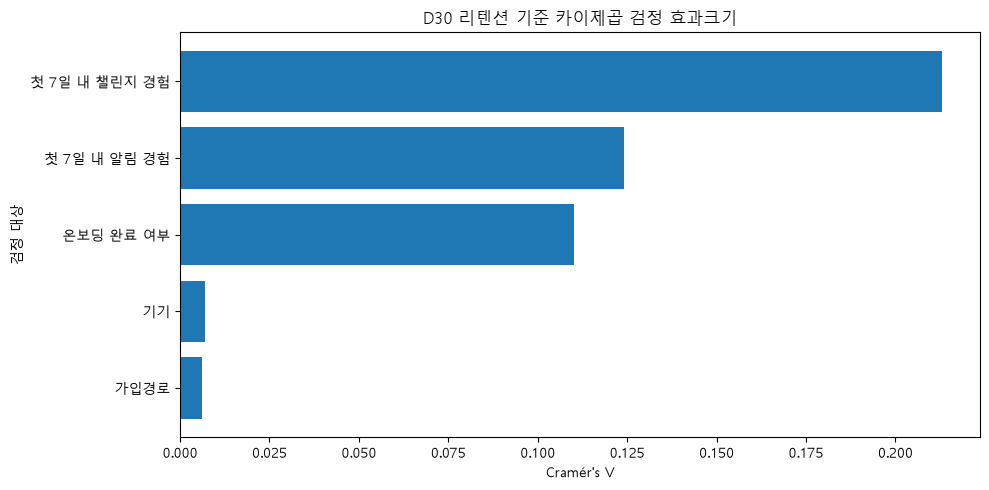

In [16]:
# D30 기준 Cramér's V 시각화
plot_chi = chi_square_result_display[chi_square_result_display["retention_label"] == "D30"].copy()
plot_chi = plot_chi.sort_values("cramers_v")

plt.figure(figsize=(10, 5))
plt.barh(plot_chi["test_name"], plot_chi["cramers_v"])

plt.xlabel("Cramér's V")
plt.ylabel("검정 대상")
plt.title("D30 리텐션 기준 카이제곱 검정 효과크기")

plt.tight_layout()
plt.show()

# 카이제곱 검정 종합 해석

카이제곱 검정 결과, D30 리텐션은 **가입경로나 기기보다 초기 행동 경험과 더 강하게 연결**되어 있었다.

| 우선순위 | 요인 | 근거 | 전략 연결 |
|---:|---|---|---|
| 1 | 첫 7일 내 챌린지 참여 | D30 기준 χ²=587.186, Cramér's V=0.224 | 온보딩 이후 챌린지 참여까지 유도하는 실험 필요 |
| 2 | 첫 7일 내 알림 오픈 | D30 기준 χ²=240.945, Cramér's V=0.143 | 알림 발송량보다 오픈 후 행동 연결 개선 필요 |
| 3 | 온보딩 완료 | D30 기준 χ²=141.672, Cramér's V=0.110 | 온보딩 완료율 개선은 기본 조건 |
| 보류 | 가입경로 / 기기 | p-value가 0.05보다 큼 | 현재 데이터만으로는 주요 원인으로 보기 어려움 |

최종적으로 두 비율 z-test와 카이제곱 검정 모두 같은 방향을 가리킨다.  
**리텐션 개선의 핵심은 신규 사용자를 가입 후 첫 7일 안에 온보딩 완료 → 챌린지 참여 → 알림 오픈 후 앱 내 행동으로 연결시키는 것이다.**